In [27]:
import pyemu
import flopy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

tmp_d = r'..\models\local2\local2'

In [28]:
sim = flopy.mf6.MFSimulation.load(sim_ws=tmp_d, verbosity_level=0) #modflow.Modflow.load(fs.MODEL_NAM,model_ws=working_dir,load_only=[])
gwf= sim.get_model()
ibound=gwf.dis.idomain.get_data()

## top

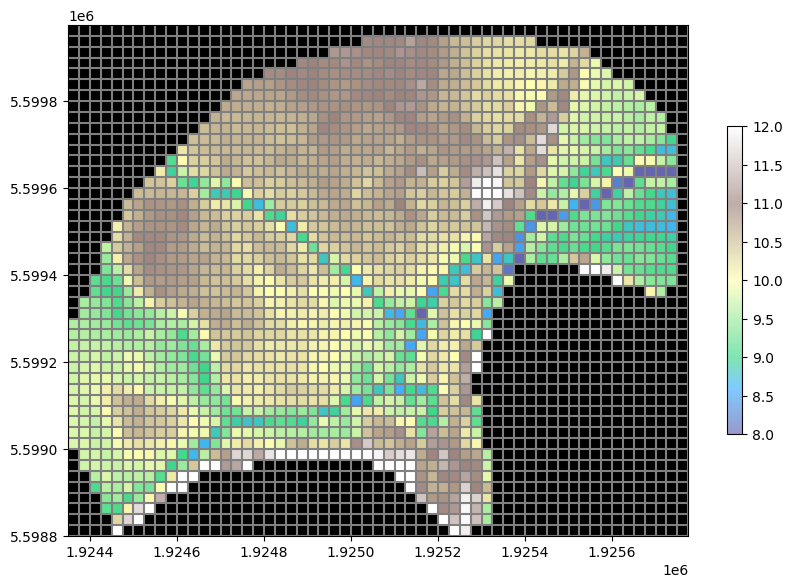

In [29]:
top = gwf.dis.top.array
# plot ibound
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(1, 1, 1, aspect="equal")
pmv = flopy.plot.PlotMapView(model=gwf, ax=ax)
mesh = pmv.plot_array(top, masked_values=[-999.99], alpha=0.5, vmin=8, vmax=12, cmap='terrain')
# pmv.plot_bc('GHB', color='red', alpha=0.5)
pmv.plot_ibound()
pmv.plot_grid()
plt.colorbar(mesh, shrink=0.5, ax=ax)

## bottom

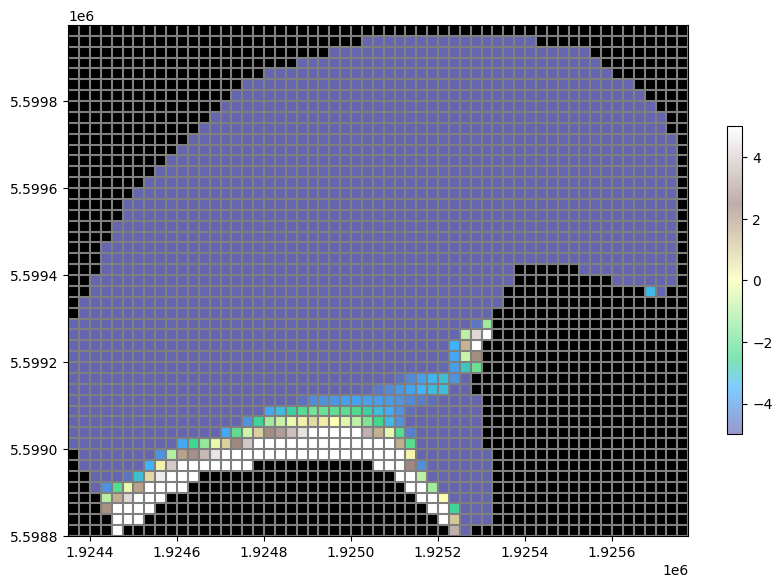

In [30]:
btm = gwf.dis.botm.array
# plot ibound
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(1,1,1, aspect="equal")
pmv = flopy.plot.PlotMapView(model=gwf, ax=ax)
mesh = pmv.plot_array(btm, masked_values=[-999.99], alpha=0.5, vmin=-5, vmax=5, cmap='terrain')
# pmv.plot_bc('GHB', color='red', alpha=0.5)
pmv.plot_ibound()
pmv.plot_grid()
plt.colorbar(mesh, shrink=0.5, ax=ax)


## thickness

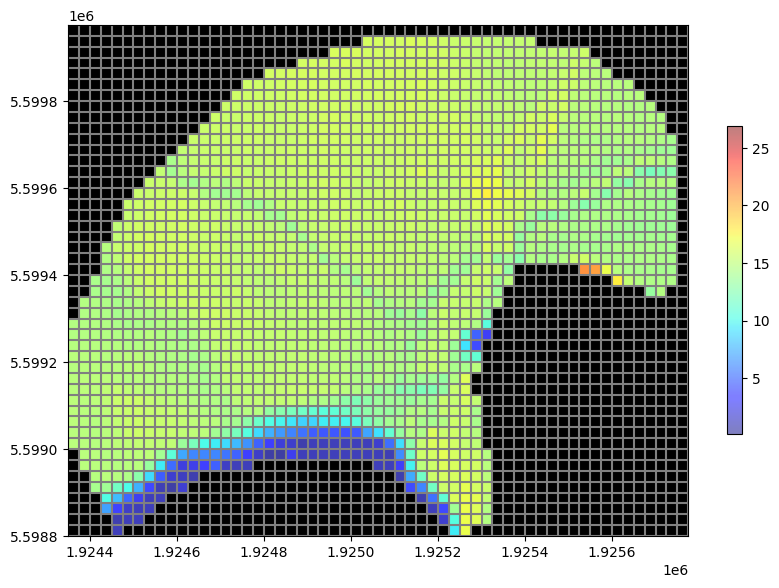

In [31]:
b = top - btm
# plot ibound
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(1,1,1, aspect="equal")
pmv = flopy.plot.PlotMapView(model=gwf, ax=ax)
mesh = pmv.plot_array(b, masked_values=[-999.99], alpha=0.5, cmap='jet')
# pmv.plot_bc('GHB', color='red', alpha=0.5)
pmv.plot_ibound()
pmv.plot_grid()
plt.colorbar(mesh, shrink=0.5, ax=ax)

## hydraulic conductivity

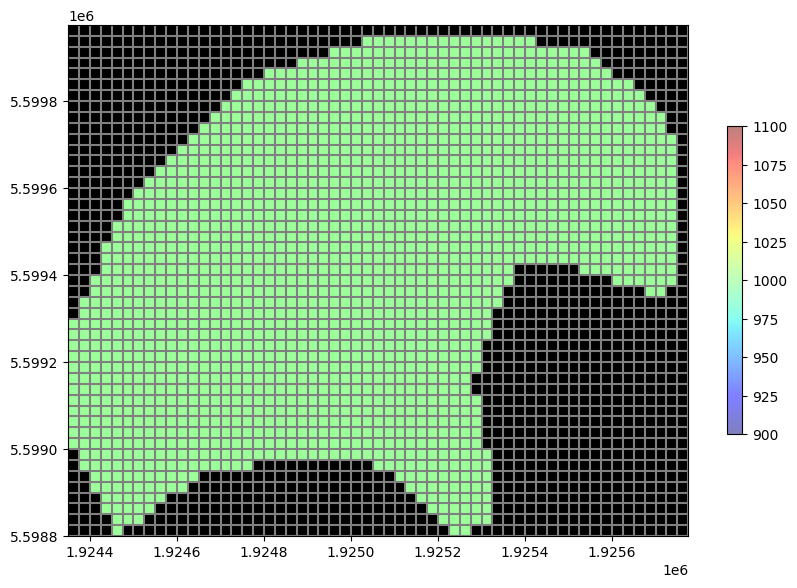

In [32]:
k = gwf.npf.k.array

# plot ibound
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(1,1,1, aspect="equal")
pmv = flopy.plot.PlotMapView(model=gwf, ax=ax)
mesh = pmv.plot_array(k, masked_values=[-999.99], alpha=0.5, cmap='jet')
# pmv.plot_bc('GHB', color='red', alpha=0.5)
pmv.plot_ibound()
pmv.plot_grid()
plt.colorbar(mesh, shrink=0.5, ax=ax)

## heads

In [33]:
head_fn = r'..\models\local2\local2\local2_heads.csv'
heads = pd.read_csv(head_fn)


In [34]:
heads.min()

i       0.000000
j       0.000000
head    8.058249
kper    1.000000
kstp    1.000000
dtype: float64

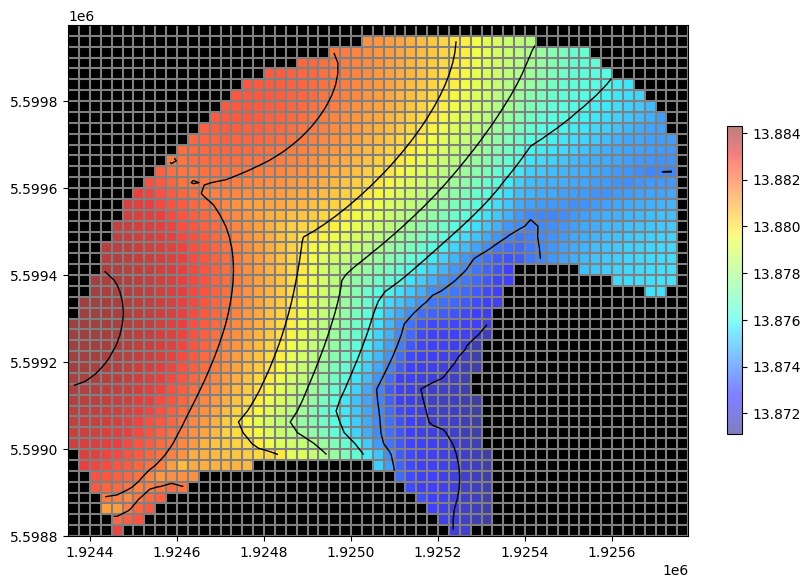

In [35]:
kper = 1
kstp = 1
filtered = heads[(heads['kper'] == kper) & (heads['kstp'] == kstp)]
arr = filtered.pivot(index='i', columns='j', values='head').to_numpy()
max_nan = 1e+30
arr = np.where(arr == max_nan, np.nan, arr)

# plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(1,1,1, aspect="equal")
pmv = flopy.plot.PlotMapView(model=gwf, ax=ax)
# pmv.contour_array(arr, masked_values=[-999.99], colors='black', linewidths=0.5)
mesh = pmv.plot_array(arr, masked_values=[1e30], alpha=0.5, cmap='jet')
# pmv.plot_bc('GHB', color='red', alpha=0.5)
pmv.plot_ibound()
pmv.plot_grid()
pmv.contour_array(arr, masked_values=[1e30], colors='black', linewidths=1)
plt.colorbar(mesh, shrink=0.5, ax=ax)

## budget

In [36]:
fn = r'..\models\local2\local2\incremental_budget.csv'
budget = pd.read_csv(fn)

In [37]:
budget

,kper,bghbaw,bghbconf,bghbpw,bghbspring,in-out,percentdiscrepancy,brcha,bstoss,btotal,bawtotal
0,1,-759.3831,-609.8318,-154.9312,-77.2212,-1.3674,-0.09,1600.0,0.0000,-1.367432,-836.6043
1,2,-980.3648,-13040.2460,-203.1282,-97.4314,0.1295,0.00,1600.0,12721.3000,0.129883,-1077.7961
2,3,-2245.6167,681.5762,-34.3125,0.0000,1.6468,0.07,1600.0,0.0000,1.646729,-2245.6167
3,4,-2245.6511,681.2780,-34.3143,0.0000,0.8182,0.04,1600.0,-0.4944,0.818359,-2245.6511


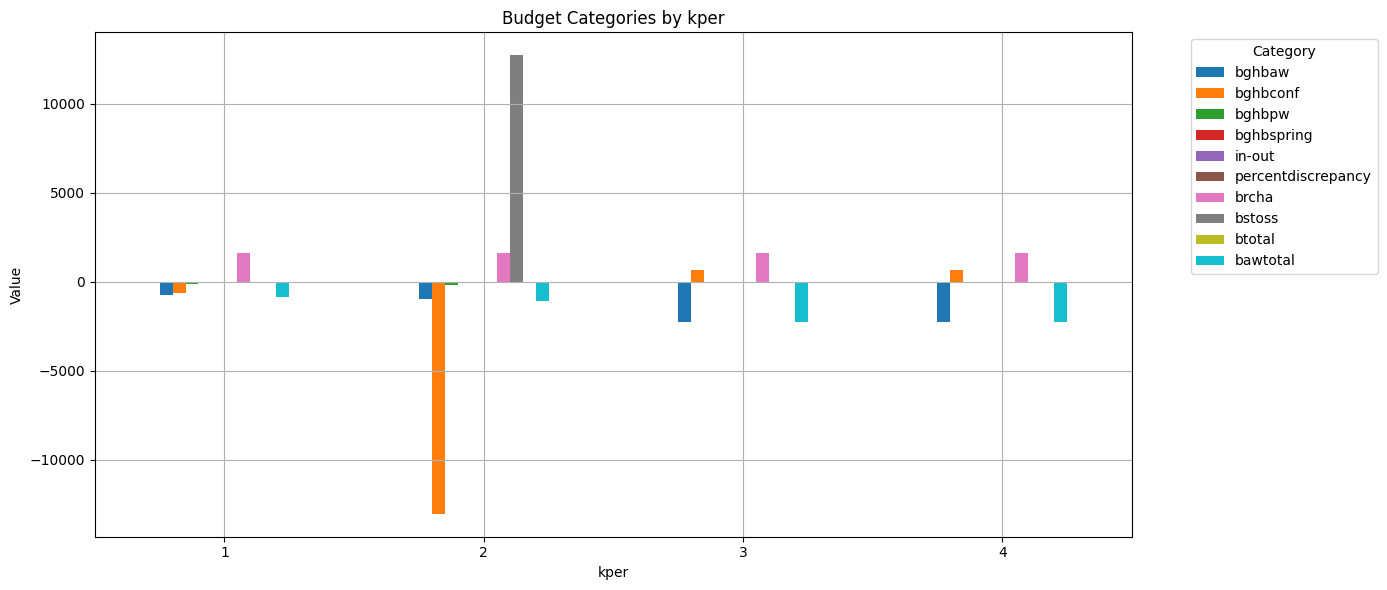

In [38]:
# Set 'kper' as x-axis and plot all other columns as grouped bars
categories = [col for col in budget.columns if col != 'kper']

budget_plot = budget.set_index('kper')[categories]

ax = budget_plot.plot(kind='bar', figsize=(14, 6))
plt.xlabel('kper')
plt.ylabel('Value')
plt.title('Budget Categories by kper')
plt.xticks(rotation=0)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='both')
plt.tight_layout()
plt.show()

## timeseries heads

In [39]:
cfn = r'..\models\local2\local2\local2.ghb_conf_heads.csv'
pwfn = r'..\models\local2\local2\local2.ghb_pw_heads.csv'
awfn = r'..\models\local2\local2\local2.awanui_stage.csv'
springfn = r'..\models\local2\local2\local2.spring_stage.csv'
conf_h = pd.read_csv(cfn)
pw_h = pd.read_csv(pwfn)
aw_h = pd.read_csv(awfn)
spring_h = pd.read_csv(springfn)

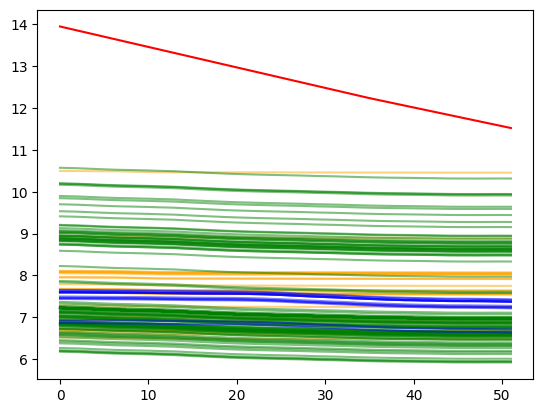

In [40]:
conf_h['heads_ts'].plot(color='red')

for col in pw_h.columns:
    if col != '#time':
        pw_h[col].plot(color = 'orange', alpha=0.5)

for col in aw_h.columns:
    if col != '#time':
        aw_h[col].plot(color = 'green', alpha=0.5)

for col in spring_h.columns:
    if col != '#time':
        spring_h[col].plot(color = 'blue', alpha=0.5)

Text(0, 0.5, 'Hydraulic Head (mRL)')

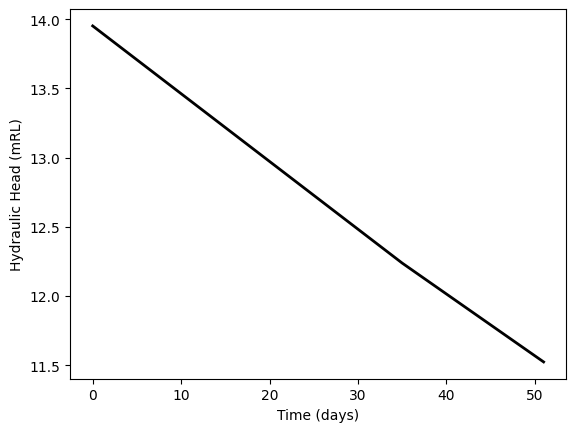

In [42]:
# normalize conf_h['heads_ts'] between -1 and 1
# conf_h['heads_ts'] = (conf_h['heads_ts'] - conf_h['heads_ts'].min()) / (conf_h['heads_ts'].max() - conf_h['heads_ts'].min()) * 2 - 1
conf_h['heads_ts'].plot(color='black', linewidth=2)
# (conf_h['heads_ts']+0.1).plot(color='orange')
# (conf_h['heads_ts']*2).plot(color='orange')
# (conf_h['heads_ts']*2+0.1).plot(color='orange')
# (conf_h['heads_ts']*0.5).plot(color='orange')
# (conf_h['heads_ts']*0.5+0.1).plot(color='orange')
plt.xlabel('Time (days)')
plt.ylabel('Hydraulic Head (mRL)')

<Axes: >

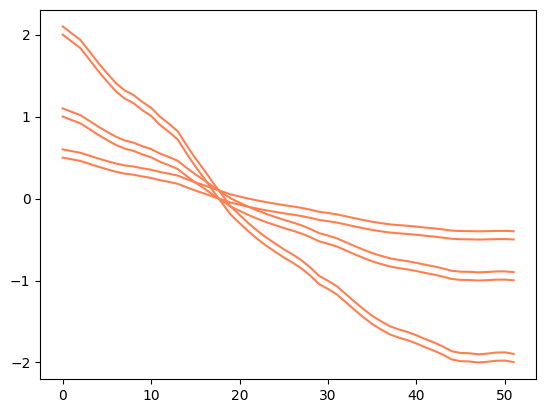

In [17]:
col = aw_h.columns[1]

# normalize aw_h[col] between -1 and 1
aw_h[col] = (aw_h[col] - aw_h[col].min()) / (aw_h[col].max() - aw_h[col].min()) * 2 - 1
aw_h[col].plot(color='coral')
(aw_h[col] + 0.1).plot(color='coral')
(aw_h[col] * 2).plot(color='coral')
(aw_h[col] * 2 + 0.1).plot(color='coral')
(aw_h[col] * 0.5).plot(color='coral')
(aw_h[col] * 0.5 + 0.1).plot(color='coral')

<Axes: >

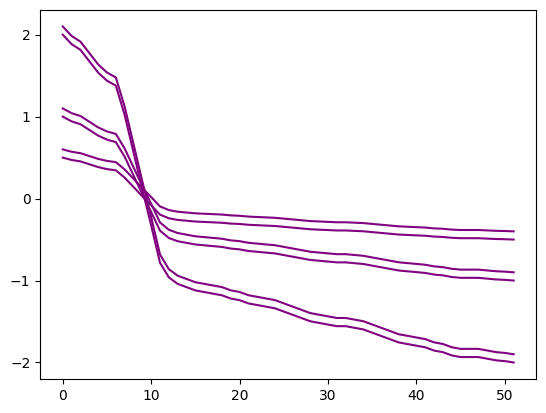

In [18]:
col = pw_h.columns[1]

# normalize pw_h[col] between -1 and 1
pw_h[col] = (pw_h[col] - pw_h[col].min()) / (pw_h[col].max() - pw_h[col].min()) * 2 - 1
pw_h[col].plot(color='purple')
(pw_h[col] + 0.1).plot(color='purple')
(pw_h[col] * 2).plot(color='purple')
(pw_h[col] * 2 + 0.1).plot(color='purple')
(pw_h[col] * 0.5).plot(color='purple')
(pw_h[col] * 0.5 + 0.1).plot(color='purple')

<Axes: >

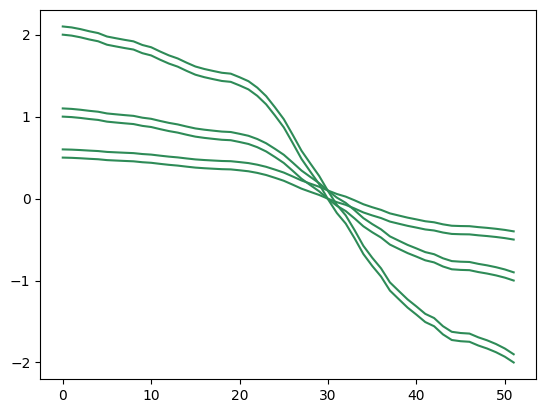

In [19]:
col = spring_h.columns[1]

# normalize spring_h[col] between -1 and 1
spring_h[col] = (spring_h[col] - spring_h[col].min()) / (spring_h[col].max() - spring_h[col].min()) * 2 - 1
spring_h[col].plot(color='seagreen')
(spring_h[col] + 0.1).plot(color='seagreen')
(spring_h[col] * 2).plot(color='seagreen')
(spring_h[col] * 2 + 0.1).plot(color='seagreen')
(spring_h[col] * 0.5).plot(color='seagreen')
(spring_h[col] * 0.5 + 0.1).plot(color='seagreen')

## pilotpoints

In [20]:
nam_f = r'..\models\local2\pest\local2_template\local2.nam'
pp_file = r'..\models\local2\pest\local2_template\npfklayer1-pp_inst0pp.dat'

# import with no index, whitespace delimited, and with column names
df_pp = pd.read_csv(pp_file, delim_whitespace=True, header=None, names=['name','x','y','f'], index_col=False)
df_pp.head()

C:\Users\tfo46\AppData\Local\Temp\ipykernel_31064\950982573.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
C:\Users\tfo46\AppData\Local\Temp\ipykernel_31064\950982573.py:5: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.


,name,x,y,f
0,pp_0000,687.5,1112.5,1
1,pp_0001,812.5,1112.5,1
2,pp_0002,937.5,1112.5,1
3,pp_0003,1062.5,1112.5,1
4,pp_0004,1187.5,1112.5,1


   could not remove start_datetime


Text(0.5, 1.0, 'Uncertainty Factors')

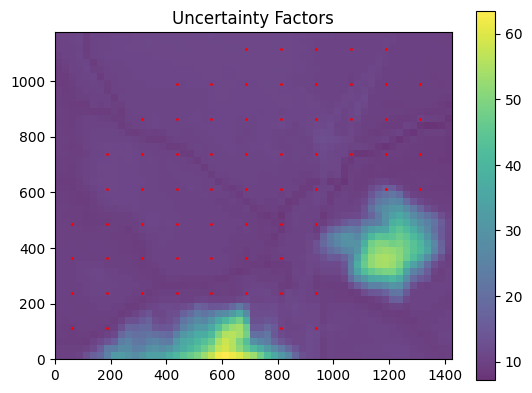

In [21]:
sr = pyemu.helpers.SpatialReference.from_namfile(
        nam_f,
        delr=gwf.dis.delr.array, delc=gwf.dis.delc.array)

# arr_var = np.loadtxt(var_f)
ax = plt.subplot(111,aspect="equal")
p = ax.imshow(top, extent=sr.get_extent(), alpha=0.8)
plt.colorbar(p)
ax.scatter(df_pp.x, df_pp.y, marker='.', s=4, color='r')
ax.set_title('Uncertainty Factors')

## streams

<Axes: >

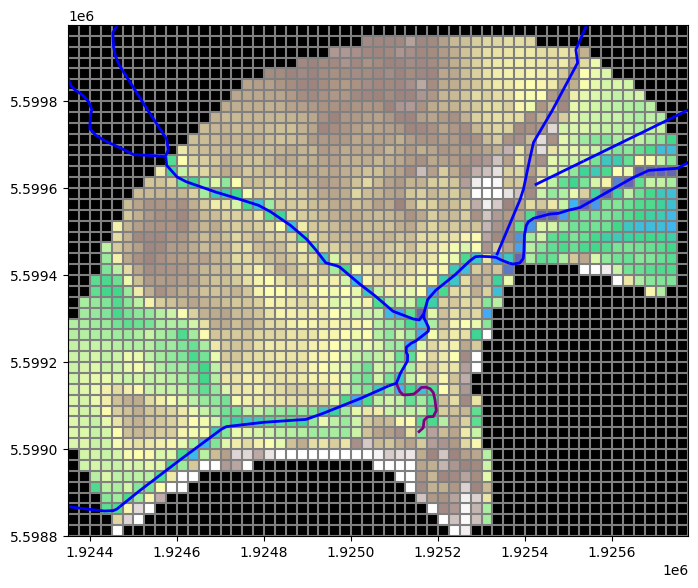

In [22]:
import geopandas as gpd
DRAINS = r"C:\Users\tfo46\e_Python\e_projects\pakipaki_01\data\drains.shp"
SPRING_DRAIN = r"C:\Users\tfo46\e_Python\e_projects\pakipaki_01\data\spring_drain.shp"


fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, aspect="equal")

pmv = flopy.plot.PlotMapView(model=gwf, ax=ax)
mesh = pmv.plot_array(top, masked_values=[-999.99], alpha=0.5, vmin=8, vmax=12, cmap='terrain')
pmv.plot_ibound()
pmv.plot_grid()

# Plot a shapefile of
drn_shp = gpd.read_file(DRAINS)
spring_drn = gpd.read_file(SPRING_DRAIN)
spring_drn.plot(ax=ax, edgecolor="purple", linewidth=2, alpha=1)
drn_shp.plot(ax=ax, edgecolor="blue", linewidth=2, alpha=1)

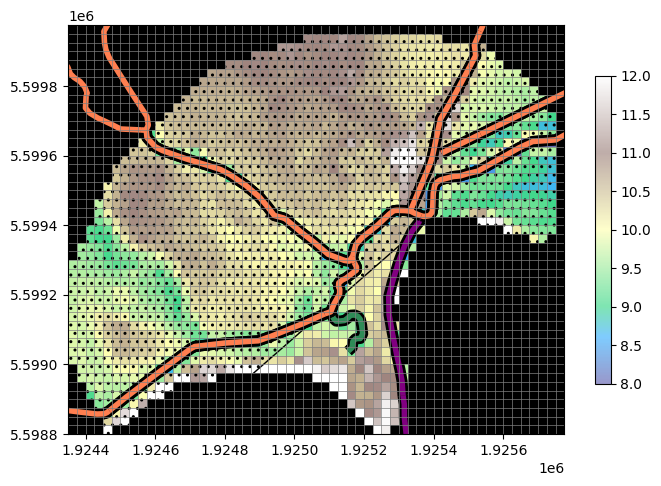

In [23]:
HBRC_DRAINS = r'C:\Users\tfo46\OneDrive - University of Canterbury\Tara_PhD\c_PhD\c_Data\a_source\sw_surface_water\HBRC_drains\HBRC_Drains.shp'
DRAINS = r"C:\Users\tfo46\e_Python\e_projects\pakipaki_01\data\drains.shp"
CONF_AREA = r"C:\Users\tfo46\e_Python\e_projects\pakipaki_01\data\confining_area.shp"

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, aspect="equal")

pmv = flopy.plot.PlotMapView(model=gwf, ax=ax)
mesh = pmv.plot_array(top, masked_values=[-999.99], alpha=0.5, vmin=8, vmax=12, cmap='terrain')

# Plot a shapefile of
drn_shp = gpd.read_file(HBRC_DRAINS)
aw_shp = gpd.read_file(DRAINS)
spring_drn = gpd.read_file(SPRING_DRAIN)
conf_area = gpd.read_file(CONF_AREA)
conf_area.plot(ax=ax, facecolor='none', edgecolor='black', hatch='..')
spring_drn.plot(ax=ax, edgecolor="black", linewidth=8, alpha=1)
spring_drn.plot(ax=ax, edgecolor="seagreen", linewidth=4, alpha=1)
drn_shp.plot(ax=ax, edgecolor="black", linewidth=8, alpha=1)
drn_shp.plot(ax=ax, edgecolor="purple", linewidth=4, alpha=1)
aw_shp.plot(ax=ax, edgecolor="black", linewidth=8, alpha=1)
aw_shp.plot(ax=ax, edgecolor="coral", linewidth=4, alpha=1)
pmv.plot_ibound()
pmv.plot_grid(linewidth=0.5)
plt.colorbar(mesh, shrink=0.5, ax=ax)

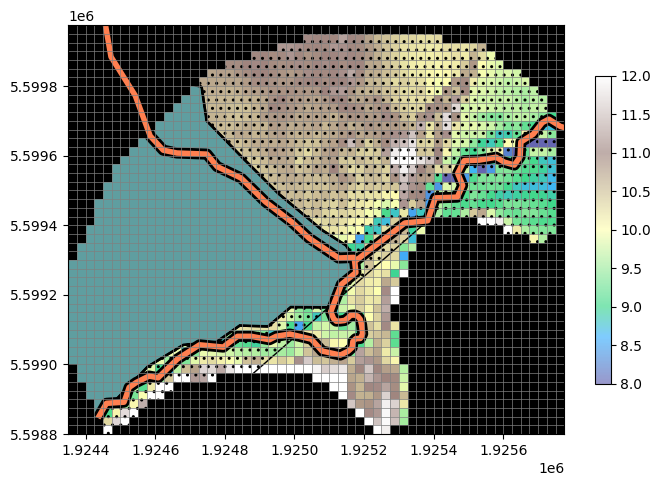

In [24]:
#past
PW_PAST = r"C:\Users\tfo46\e_Python\e_projects\pakipaki_01\data/poukawa_past.shp"
DRAINS_PAST = r"C:\Users\tfo46\e_Python\e_projects\pakipaki_01\data/drains_past.shp"
WETLANDA_PAST = r"C:\Users\tfo46\e_Python\e_projects\pakipaki_01\data/wetlandA_past.shp"
CONF_AREA = r"C:\Users\tfo46\e_Python\e_projects\pakipaki_01\data\confining_area.shp"

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(1, 1, 1, aspect="equal")

pmv = flopy.plot.PlotMapView(model=gwf, ax=ax)
mesh = pmv.plot_array(top, masked_values=[-999.99], alpha=0.5, vmin=8, vmax=12, cmap='terrain')

# Plot a shapefile of
pw_shp = gpd.read_file(PW_PAST)
drn_shp = gpd.read_file(DRAINS_PAST)
wetland_drn = gpd.read_file(WETLANDA_PAST)
conf_area = gpd.read_file(CONF_AREA)
conf_area.plot(ax=ax, facecolor='none', edgecolor='black', hatch='..')
# pw_shp.plot(ax=ax, edgecolor="black", linewidth=8, alpha=1)
# pw_shp.plot(ax=ax, edgecolor="coral", linewidth=4, alpha=1)
drn_shp.plot(ax=ax, edgecolor="black", linewidth=8, alpha=1)
drn_shp.plot(ax=ax, edgecolor="coral", linewidth=4, alpha=1)
wetland_drn.plot(ax=ax, color='cadetblue', edgecolor='black', linewidth=4, alpha=1)
wetland_drn.plot(ax=ax, color='cadetblue', alpha=1)
pmv.plot_ibound()
pmv.plot_grid(linewidth=0.5)
plt.colorbar(mesh, shrink=0.5, ax=ax)